In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import pickle
import os 



# Simulate on sequence depth 

In [ ]:
mean, var= 2, 20
dispersion = var / mean 

N_windows = 249*10e6 // 3000 

a = (var + mean**2 - mean) / (var + mean)

freq_0_open_region = M1/a - M1

In [9]:
np.random.binomial(n=10, p=0.1, size=3)

array([2, 0, 3])

In [54]:
a = np.random.poisson(lam=2, size=3)
a

array([0, 2, 2])

In [58]:
np.concatenate((a, [1, None]))

array([0, 2, 2, 1, None], dtype=object)

In [20]:
N_windows = 249*10e6 // 3000 


def simulate_tn5_insertions(n_sample, poisson_rate = 2, N_windows=N_windows, non0_rate=0.02, seed=0 ):
    """
    Simulate Tn5 insertions across a genome of given size.
    
    Parameters:
    n_sample (int): Number of samples to simulate.
    chromosome_size (int): Size of the chromosome (default is 249e6 for human genome).

    Returns:
    lis of tuples: Each tuple contains (n_closedregion_windows, unique_non0_insertions, corresponding_frequencies)
    """
    np.random.seed(seed=seed)
    
    sample_record = []
    open_region_windows = np.random.binomial(n=N_windows, p=non0_rate, size=n_sample)
    # each element is for one sample/BC
    for n_open_wd in open_region_windows:
        if n_open_wd ==0:
            sample_record.append((N_windows, None, None))
        else:
            tn5_insert = np.random.poisson(lam=poisson_rate, size=n_open_wd)
            ocur, freq = np.unique(tn5_insert, return_counts=True)
            if ocur[0] ==0:
                sample_record.append((N_windows-n_open_wd, ocur[1:], freq[1:]))
            else:
                sample_record.append((N_windows-n_open_wd, ocur, freq))
    return sample_record

In [21]:
tn5_insertion_samples = simulate_tn5_insertions(n_sample=10 )

In [22]:
tn5_insertion_samples

[(813396.0,
  array([1, 2, 3, 4, 5, 6, 7, 8, 9]),
  array([4564, 4543, 2905, 1460,  567,  186,   71,   14,    4])),
 (813330.0,
  array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10]),
  array([4480, 4508, 3051, 1488,  607,  196,   70,   20,    3,    1])),
 (813423.0,
  array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10]),
  array([4428, 4490, 2992, 1498,  650,  177,   63,   18,    3,    1])),
 (813486.0,
  array([1, 2, 3, 4, 5, 6, 7, 8, 9]),
  array([4462, 4457, 2980, 1485,  651,  215,   67,   13,    3])),
 (813732.0,
  array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11]),
  array([4488, 4320, 2974, 1435,  593,  186,   49,   12,    3,    1,    1])),
 (813447.0,
  array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 11]),
  array([4452, 4543, 2959, 1516,  538,  176,   58,   14,    2,    1])),
 (813398.0,
  array([1, 2, 3, 4, 5, 6, 7, 8, 9]),
  array([4510, 4494, 2944, 1444,  629,  195,   57,   13,    1])),
 (813622.0,
  array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10]),
  array([4432, 4385, 3029, 1487,  580, 

In [27]:
def calculate_close_region_windows(non0_tn5_insertion_record, N_windows):
    """
    Calculate the number of closed region windows 
    from the TN5 insertion record.

    """
    
    non0_ocur, freq = non0_tn5_insertion_record
    
    p_prime = freq / np.sum(freq)
    
    M1 = freq.sum()
    y2_expect = np.sum( non0_ocur**2 * p_prime )
    y1_expect = np.sum( non0_ocur * p_prime )

    a = (y2_expect - y1_expect) / (y1_expect**2)
    freq_0_open_region = M1/a - M1
    return N_windows - int(freq_0_open_region)

In [28]:
tn5_insertion_samples[0][1:]

(array([1, 2, 3, 4, 5, 6, 7, 8, 9]),
 array([4564, 4543, 2905, 1460,  567,  186,   71,   14,    4]))

In [30]:
calculate_close_region_windows(tn5_insertion_samples[0][1:], N_windows), tn5_insertion_samples[0][0]

(827765.0, 813396.0)

In [39]:
predicted_closed_wd = np.array([calculate_close_region_windows(x[1:], N_windows) for x in tn5_insertion_samples])
observed_closed_wd = np.array([x[0] for x in tn5_insertion_samples])

In [44]:
predicted_closed_wd.mean() - observed_closed_wd.mean()

14321.20000000007

In [41]:
(predicted_closed_wd - observed_closed_wd) / observed_closed_wd

array([0.01766544, 0.0178095 , 0.01767961, 0.01770528, 0.01725875,
       0.01742338, 0.01765065, 0.01732746, 0.01789424, 0.01764346])

Text(0, 0.5, 'Predicted closed region windows')

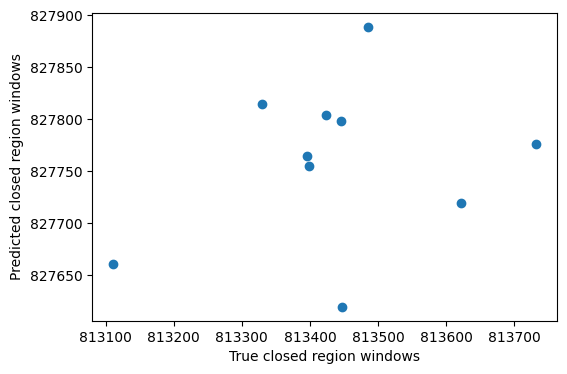

In [38]:
fig, ax = plt.subplots(figsize=(6,4))
ax.scatter([x[0] for x in tn5_insertion_samples], predicted_closed_wd)
#ax.plot([0, N_windows], [0, N_windows], color='red', linestyle='--')
ax.set_xlabel('True closed region windows')
ax.set_ylabel('Predicted closed region windows')

In [49]:
def calculate_expected_close_region_windows(tn5_insertion_samples, N_windows):
    """
    Calculate the number of closed region windows 
    from the TN5 insertion record.

    """
    
    stats_record = {}
    stats_record['M1'] = []
    stats_record['y1_expect'] = []
    stats_record['y2_expect'] = []
    for record in tn5_insertion_samples:
        non0_ocur, freq = record[1:]
        M1 = freq.sum()
        
        p_prime = freq / np.sum(freq)
        
        y2_expect = np.sum( non0_ocur**2 * p_prime )
        y1_expect = np.sum( non0_ocur * p_prime )
        
        #stats_record.append((M1, y1_expect, y2_expect))
        stats_record['M1'].append(M1)
        stats_record['y1_expect'].append(y1_expect)
        stats_record['y2_expect'].append(y2_expect)
    
    M1_est = np.sum(stats_record['M1'])    
    weight = np.array(stats_record['M1']) / M1_est
    
    y1_expect_est = np.sum( np.array(stats_record['y1_expect']) * weight )
    y2_expect_est = np.sum( np.array(stats_record['y2_expect']) * weight )

    a = (y2_expect_est - y1_expect_est) / (y1_expect_est**2)
    freq_0_open_region = M1_est/a - M1_est
    return N_windows - int(freq_0_open_region)
    


In [52]:
calculate_expected_close_region_windows(tn5_insertion_samples, N_windows) - observed_closed_wd.mean()


-5825.099999999977